# 1.7 Segmentacion con Inteligencia Artificial — TensorFlow / Keras

Este notebook implementa segmentacion semantica con el dataset **Oxford-IIIT Pet**, descargado automaticamente con `tensorflow_datasets`. Se trabajan dos arquitecturas (FCN y U-Net), cinco funciones de perdida y todas las metricas estandar del campo.

El dataset Oxford Pet contiene 7,349 imagenes de mascotas con mascaras de segmentacion en 3 clases:
- **Clase 0 — Mascota** (foreground)
- **Clase 1 — Fondo** (background)
- **Clase 2 — Borde** (no clasificado / contorno)

Las mascaras vienen con valores 1, 2, 3 que se remapean a 0, 1, 2.

---

## Contenidos

1. Fundamentos y formulacion matematica
2. Dataset Oxford-IIIT Pet con tf_datasets
3. Arquitectura FCN (Fully Convolutional Network)
4. Arquitectura U-Net con skip connections
5. Funciones de perdida
6. Metricas de evaluacion
7. Data augmentation sincronizada
8. Entrenamiento y comparativa
9. Analisis de resultados

---

## 1. Fundamentos y formulacion matematica

La segmentacion semantica asigna una etiqueta de clase a cada pixel:

$$f_\theta : \mathbb{R}^{H \times W \times C} \rightarrow \{0, \ldots, K-1\}^{H \times W}$$

La red produce logits de forma $(B, H, W, K)$. La prediccion final por pixel es:

$$\hat{y}_{ij} = \arg\max_k \; \text{softmax}(\text{logits})_{ijk}$$

**Nota sobre formato**: TensorFlow usa por defecto el formato **NHWC** (batch, height, width, channels), a diferencia de PyTorch que usa NCHW. Las funciones `softmax`, `argmax` y las one-hot operan sobre el ultimo eje en TF.

A diferencia de la clasificacion, la segmentacion debe **preservar la resolucion espacial** a lo largo de la red. Esto requiere arquitecturas encoder-decoder.

---

## 2. Dataset Oxford-IIIT Pet con tensorflow_datasets

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_datasets as tfds

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

tf.random.set_seed(42)
np.random.seed(42)

print(f'TensorFlow : {tf.__version__}')
print(f'TFDS       : {tfds.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

TensorFlow : 2.20.0
TFDS       : 4.9.9
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
N_CLASSES    = 3
IMG_H, IMG_W = 128, 128
CLASS_NAMES  = ['Mascota', 'Fondo', 'Borde']
CLASS_COLORS = [
    (255, 255, 255),  # 0: mascota (foreground)
    (0,   0,   0),    # 1: fondo (background)
    (128, 128, 128),  # 2: borde / no clasificado
]

# Cargar Oxford Pet con tensorflow_datasets
# La primera vez descarga ~800 MB; despues queda en cache local
(ds_trainval, ds_test), info = tfds.load(
    'oxford_iiit_pet:4.*.*',
    split=['train', 'test'],
    with_info=True,
    shuffle_files=False,
)

print(f'Train+Val: {info.splits["train"].num_examples} imagenes')
print(f'Test     : {info.splits["test"].num_examples} imagenes')
print(f'Features : {info.features}')

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.33XQ3F_4.0.0/oxford_iiit_pet-train.tfrecord*...…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.33XQ3F_4.0.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
Train+Val: 3680 imagenes
Test     : 3669 imagenes
Features : FeaturesDict({
    'file_name': Text(shape=(), dtype=string),
    'head_bbox': BBoxFeature(shape=(4,), dtype=float32),
    'image': Image(shape=(None, None, 3), dtype=uint8),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=37),
    'segmentation_mask': Image(shape=(None, None, 1), dtype=uint8),
    'species': ClassLabel(shape=(), dtype=int64, num_classes=2),
})


In [4]:
@tf.function
def load_image(datapoint):
    """
    Procesa un ejemplo del dataset:
    - Resize de imagen y mascara a (IMG_H, IMG_W).
    - Normalizar imagen a [0, 1].
    - Remapear mascara: 1->0, 2->1, 3->2  (las mascaras de Oxford Pet
      usan valores 1, 2, 3; las redes esperan 0..K-1).
    """
    img  = tf.image.resize(datapoint['image'],          [IMG_H, IMG_W])
    mask = tf.image.resize(
        datapoint['segmentation_mask'],
        [IMG_H, IMG_W],
        method=tf.image.ResizeMethod.NEAREST_NEIGHBOR  # NEAREST para no interpolar etiquetas
    )
    img  = tf.cast(img,  tf.float32) / 255.0
    mask = tf.cast(mask, tf.int32) - 1                 # 1,2,3 -> 0,1,2
    mask = tf.squeeze(mask, axis=-1)                   # (H, W, 1) -> (H, W)
    return img, mask


# Pipeline de datos
BATCH_SIZE  = 16
BUFFER_SIZE = 1000

# 80% del trainval para entrenamiento, 20% para validacion
n_total    = info.splits['train'].num_examples
n_val      = int(n_total * 0.2)

ds_processed = ds_trainval.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
ds_val_raw   = ds_processed.take(n_val)
ds_train_raw = ds_processed.skip(n_val)
ds_test_proc = ds_test.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

train_ds = (ds_train_raw.cache()
            .shuffle(BUFFER_SIZE)
            .batch(BATCH_SIZE, drop_remainder=True)
            .prefetch(tf.data.AUTOTUNE))
val_ds   = (ds_val_raw.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))
test_ds  = (ds_test_proc.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

# Verificar
for imgs_b, masks_b in train_ds.take(1):
    print(f'Batch imagenes : {imgs_b.shape}   (B, H, W, C)')
    print(f'Batch mascaras : {masks_b.shape}  (B, H, W)')
    print(f'Clases unicas  : {sorted(np.unique(masks_b.numpy()).tolist())}')

Batch imagenes : (16, 128, 128, 3)   (B, H, W, C)
Batch mascaras : (16, 128, 128)  (B, H, W)
Clases unicas  : [0, 1, 2]


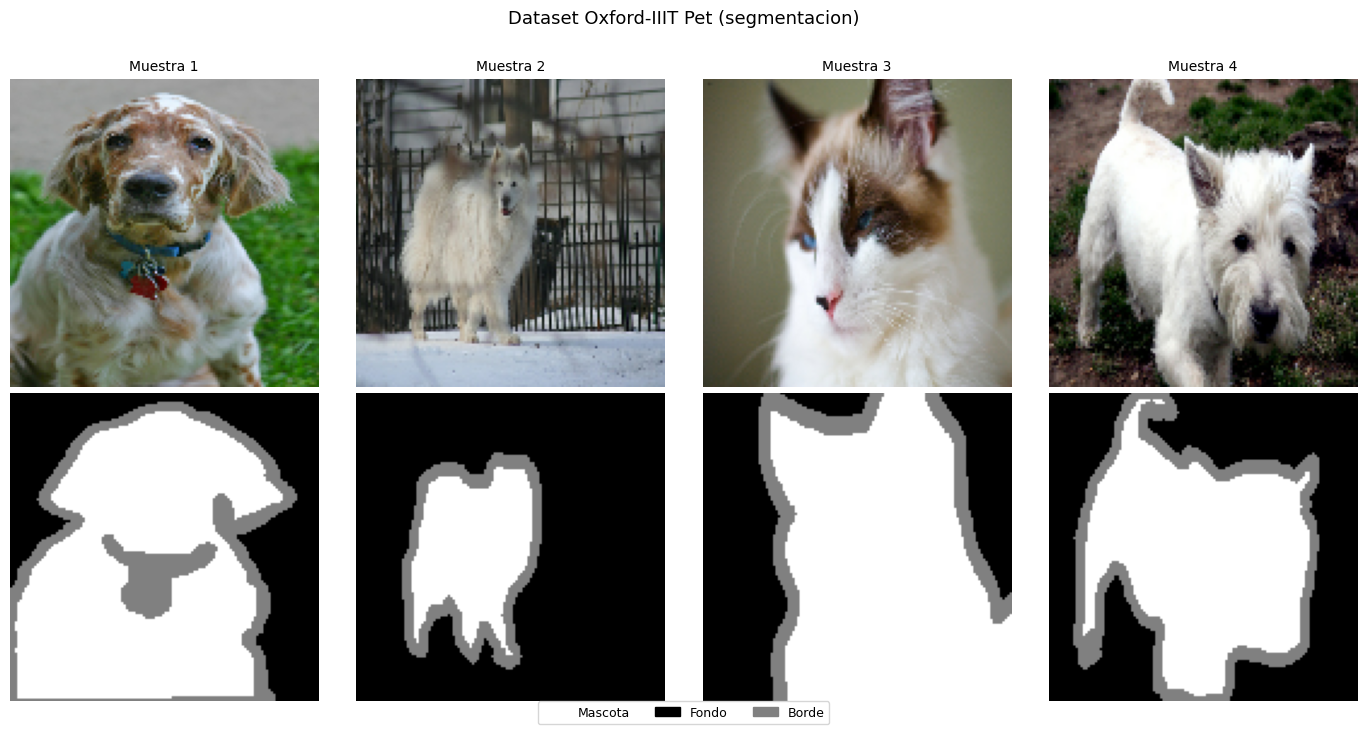

In [5]:
def mask_to_rgb(mask):
    """Convierte mascara entera a imagen RGB para visualizacion."""
    rgb = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for c, col in enumerate(CLASS_COLORS):
        rgb[mask == c] = col
    return rgb


# Visualizar ejemplos del dataset
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, (img, mask) in enumerate(ds_train_raw.take(4)):
    axes[0, i].imshow(img.numpy())
    axes[0, i].set_title(f'Muestra {i+1}', fontsize=10)
    axes[0, i].axis('off')
    axes[1, i].imshow(mask_to_rgb(mask.numpy()))
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Imagen', fontsize=11, rotation=0, labelpad=40, va='center')
axes[1, 0].set_ylabel('Mascara', fontsize=11, rotation=0, labelpad=40, va='center')

handles = [mpatches.Patch(color=[c/255 for c in col], label=name)
           for col, name in zip(CLASS_COLORS, CLASS_NAMES)]
fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.02))
plt.suptitle('Dataset Oxford-IIIT Pet (segmentacion)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [6]:
# Analisis de desbalance de clases
class_counts = np.zeros(N_CLASSES)
for _, masks in train_ds.take(50):                        # muestreo rapido
    for c in range(N_CLASSES):
        class_counts[c] += np.sum(masks.numpy() == c)

class_freqs   = class_counts / class_counts.sum()
class_weights = 1.0 / (class_freqs + 1e-6)
class_weights = (class_weights / class_weights.sum() * N_CLASSES).astype('float32')

print('Distribucion de pixeles por clase:')
for c in range(N_CLASSES):
    barra = '#' * int(class_freqs[c] * 50)
    print(f'  {CLASS_NAMES[c]:<10}: {class_freqs[c]*100:5.1f}%  {barra}')

print('\nPesos de clase (inverse frequency):')
for c in range(N_CLASSES):
    print(f'  {CLASS_NAMES[c]:<10}: {class_weights[c]:.3f}')

Distribucion de pixeles por clase:
  Mascota   :  30.3%  ###############
  Fondo     :  58.5%  #############################
  Borde     :  11.3%  #####

Pesos de clase (inverse frequency):
  Mascota   : 0.715
  Fondo     : 0.370
  Borde     : 1.916


---

## 3. Arquitectura FCN (Fully Convolutional Network)

Long et al. (2015) propusieron sustituir las capas densas finales de una CNN por convoluciones $1 \times 1$ y recuperar la resolucion con upsampling bilineal.

**Limitacion:** el upsampling desde $H/16$ produce bordes difusos.

In [7]:
def conv_block(x, filters, n_convs=2):
    """Bloque de n convoluciones seguidas: Conv -> BN -> ReLU."""
    for _ in range(n_convs):
        x = layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
    return x


def build_fcn(n_classes=3, in_shape=(128, 128, 3), base=32):
    """
    FCN para segmentacion.
    Encoder: 4 niveles de doble conv + MaxPool (reduccion x16).
    Cabeza : Conv 1x1 produce K logits por ubicacion espacial.
    Decoder: UpSampling bilineal restaura la resolucion original.
    """
    inputs = keras.Input(shape=in_shape)
    x = inputs
    x = conv_block(x, base);    x = layers.MaxPooling2D(2)(x)   # H/2
    x = conv_block(x, base*2);  x = layers.MaxPooling2D(2)(x)   # H/4
    x = conv_block(x, base*4);  x = layers.MaxPooling2D(2)(x)   # H/8
    x = conv_block(x, base*8);  x = layers.MaxPooling2D(2)(x)   # H/16

    # Conv 1x1 produce un logit por clase por ubicacion espacial
    x = layers.Conv2D(n_classes, 1)(x)

    # Upsample bilineal: factor 16 para volver al tamano original
    x = layers.UpSampling2D(size=16, interpolation='bilinear')(x)

    return keras.Model(inputs, x, name='fcn')


fcn_model = build_fcn(N_CLASSES, (IMG_H, IMG_W, 3))
print(f'FCN | parametros: {fcn_model.count_params():,}')
fcn_model(tf.zeros((2, IMG_H, IMG_W, 3))).shape

FCN | parametros: 1,175,907


TensorShape([2, 128, 128, 3])

---

## 4. Arquitectura U-Net con skip connections

U-Net (Ronneberger et al., 2015) añade **skip connections** que concatenan cada nivel del encoder con el nivel simetrico del decoder. Resuelve la limitacion de la FCN aportando detalle espacial fino al decoder.

In [8]:
def double_conv(x, filters):
    """Bloque doble Conv-BN-ReLU caracteristico de U-Net."""
    x = layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x


def build_unet(n_classes=3, in_shape=(128, 128, 3), f=32):
    """
    U-Net para segmentacion semantica.

    En cada nivel del decoder:
    1. Conv2DTranspose duplica la resolucion espacial.
    2. Concatenacion con el skip del encoder del mismo nivel.
    3. DoubleConv fusiona la informacion semantica y espacial.
    """
    inputs = keras.Input(shape=in_shape)

    # ---- Encoder con skip connections ----
    s1 = double_conv(inputs, f)
    p1 = layers.MaxPooling2D(2)(s1)

    s2 = double_conv(p1, f*2)
    p2 = layers.MaxPooling2D(2)(s2)

    s3 = double_conv(p2, f*4)
    p3 = layers.MaxPooling2D(2)(s3)

    s4 = double_conv(p3, f*8)
    p4 = layers.MaxPooling2D(2)(s4)

    # ---- Bottleneck ----
    bn = double_conv(p4, f*16)

    # ---- Decoder con skip connections ----
    u4 = layers.Conv2DTranspose(f*8, 2, strides=2, padding='same')(bn)
    u4 = layers.Concatenate()([u4, s4])
    u4 = double_conv(u4, f*8)

    u3 = layers.Conv2DTranspose(f*4, 2, strides=2, padding='same')(u4)
    u3 = layers.Concatenate()([u3, s3])
    u3 = double_conv(u3, f*4)

    u2 = layers.Conv2DTranspose(f*2, 2, strides=2, padding='same')(u3)
    u2 = layers.Concatenate()([u2, s2])
    u2 = double_conv(u2, f*2)

    u1 = layers.Conv2DTranspose(f, 2, strides=2, padding='same')(u2)
    u1 = layers.Concatenate()([u1, s1])
    u1 = double_conv(u1, f)

    # ---- Cabeza ----
    outputs = layers.Conv2D(n_classes, 1)(u1)

    return keras.Model(inputs, outputs, name='unet')


unet_model = build_unet(N_CLASSES, (IMG_H, IMG_W, 3), f=32)
print(f'U-Net | parametros: {unet_model.count_params():,}')
unet_model(tf.zeros((2, IMG_H, IMG_W, 3))).shape

U-Net | parametros: 7,768,995


TensorShape([2, 128, 128, 3])

---

## 5. Funciones de perdida

In [9]:
class SegLoss:
    """Funciones de perdida para segmentacion. Logits en formato NHWC."""

    @staticmethod
    def ce(y_true, y_pred):
        """Sparse Categorical Cross-Entropy. y_true entero (B,H,W)."""
        return keras.losses.sparse_categorical_crossentropy(
            y_true, y_pred, from_logits=True
        )

    @staticmethod
    def weighted_ce(class_weights):
        """Cross-Entropy ponderada por clase. Compensa el desbalance."""
        cw = tf.constant(class_weights, dtype=tf.float32)
        def loss_fn(y_true, y_pred):
            ce = keras.losses.sparse_categorical_crossentropy(
                y_true, y_pred, from_logits=True)
            # Asignar peso a cada pixel segun su clase
            sample_weights = tf.gather(cw, tf.cast(y_true, tf.int32))
            return ce * sample_weights
        return loss_fn

    @staticmethod
    def dice(n_classes, smooth=1.0):
        """
        Dice Loss = 1 - mean_c[ 2|P ∩ G| / (|P| + |G|) ]
        Trata todas las clases por igual sin importar su frecuencia.
        """
        def loss_fn(y_true, y_pred):
            y_true = tf.cast(y_true, tf.int32)
            oh     = tf.one_hot(y_true, n_classes)              # (B,H,W,K)
            probs  = tf.nn.softmax(y_pred, axis=-1)

            # Calcular Dice por clase reduciendo H y W
            inter = tf.reduce_sum(probs * oh, axis=[1, 2])      # (B, K)
            union = tf.reduce_sum(probs,      axis=[1, 2]) + tf.reduce_sum(oh, axis=[1, 2])
            dice  = (2 * inter + smooth) / (union + smooth)     # (B, K)
            return 1 - tf.reduce_mean(dice)
        return loss_fn

    @staticmethod
    def focal(gamma=2.0):
        """
        Focal Loss: multiplica CE por (1-p)^gamma.
        Reduce el peso de pixeles faciles, enfoca en bordes y clases raras.
        """
        def loss_fn(y_true, y_pred):
            y_true = tf.cast(y_true, tf.int32)
            ce     = keras.losses.sparse_categorical_crossentropy(
                y_true, y_pred, from_logits=True)
            probs  = tf.nn.softmax(y_pred, axis=-1)
            # p_t: probabilidad asignada a la clase correcta de cada pixel
            pt     = tf.gather(probs, tf.cast(y_true[..., None], tf.int32),
                              batch_dims=3)
            pt     = tf.squeeze(pt, axis=-1)
            return tf.pow(1.0 - pt, gamma) * ce
        return loss_fn

    @staticmethod
    def combined(n_classes, class_weights=None, lam=0.5):
        """CE + lambda*Dice. Combinacion mas robusta y usada en la practica."""
        dice_fn = SegLoss.dice(n_classes)
        if class_weights is not None:
            ce_fn = SegLoss.weighted_ce(class_weights)
        else:
            ce_fn = SegLoss.ce

        def loss_fn(y_true, y_pred):
            return tf.reduce_mean(ce_fn(y_true, y_pred)) + lam * dice_fn(y_true, y_pred)
        return loss_fn

---

## 6. Metricas de evaluacion

In [10]:
def iou_per_class(y_true, y_pred, n_classes):
    """IoU = TP / (TP+FP+FN). NaN para clases ausentes."""
    ious = []
    for c in range(n_classes):
        pred_c = (y_pred == c)
        gt_c   = (y_true == c)
        inter  = np.sum(pred_c & gt_c)
        union  = np.sum(pred_c | gt_c)
        ious.append(inter / union if union > 0 else float('nan'))
    return ious


def dice_per_class(y_true, y_pred, n_classes, eps=1e-6):
    """Dice/F1 = 2TP/(2TP+FP+FN)."""
    dices = []
    for c in range(n_classes):
        pred_c = (y_pred == c).astype('float32')
        gt_c   = (y_true == c).astype('float32')
        inter  = np.sum(pred_c * gt_c)
        denom  = np.sum(pred_c) + np.sum(gt_c)
        dices.append((2 * inter + eps) / (denom + eps) if denom > 0 else float('nan'))
    return dices


def evaluate(model, dataset, n_classes):
    """Evalua el modelo sobre todo el dataset y retorna metricas globales."""
    all_preds, all_targets = [], []
    for imgs, masks in dataset:
        logits = model(imgs, training=False)
        preds  = tf.argmax(logits, axis=-1).numpy()
        all_preds.append(preds)
        all_targets.append(masks.numpy())

    preds   = np.concatenate(all_preds)
    targets = np.concatenate(all_targets)

    ious  = iou_per_class(targets, preds, n_classes)
    dices = dice_per_class(targets, preds, n_classes)
    return {
        'pixel_acc'     : float(np.mean(preds == targets)),
        'mIoU'          : float(np.nanmean(ious)),
        'mean_dice'     : float(np.nanmean(dices)),
        'iou_per_class' : ious,
        'dice_per_class': dices,
        'preds': preds, 'targets': targets,
    }

---

## 7. Data augmentation sincronizada

En segmentacion, las transformaciones geometricas deben aplicarse **identicamente** a imagen y mascara. Las transformaciones de color solo se aplican a la imagen.

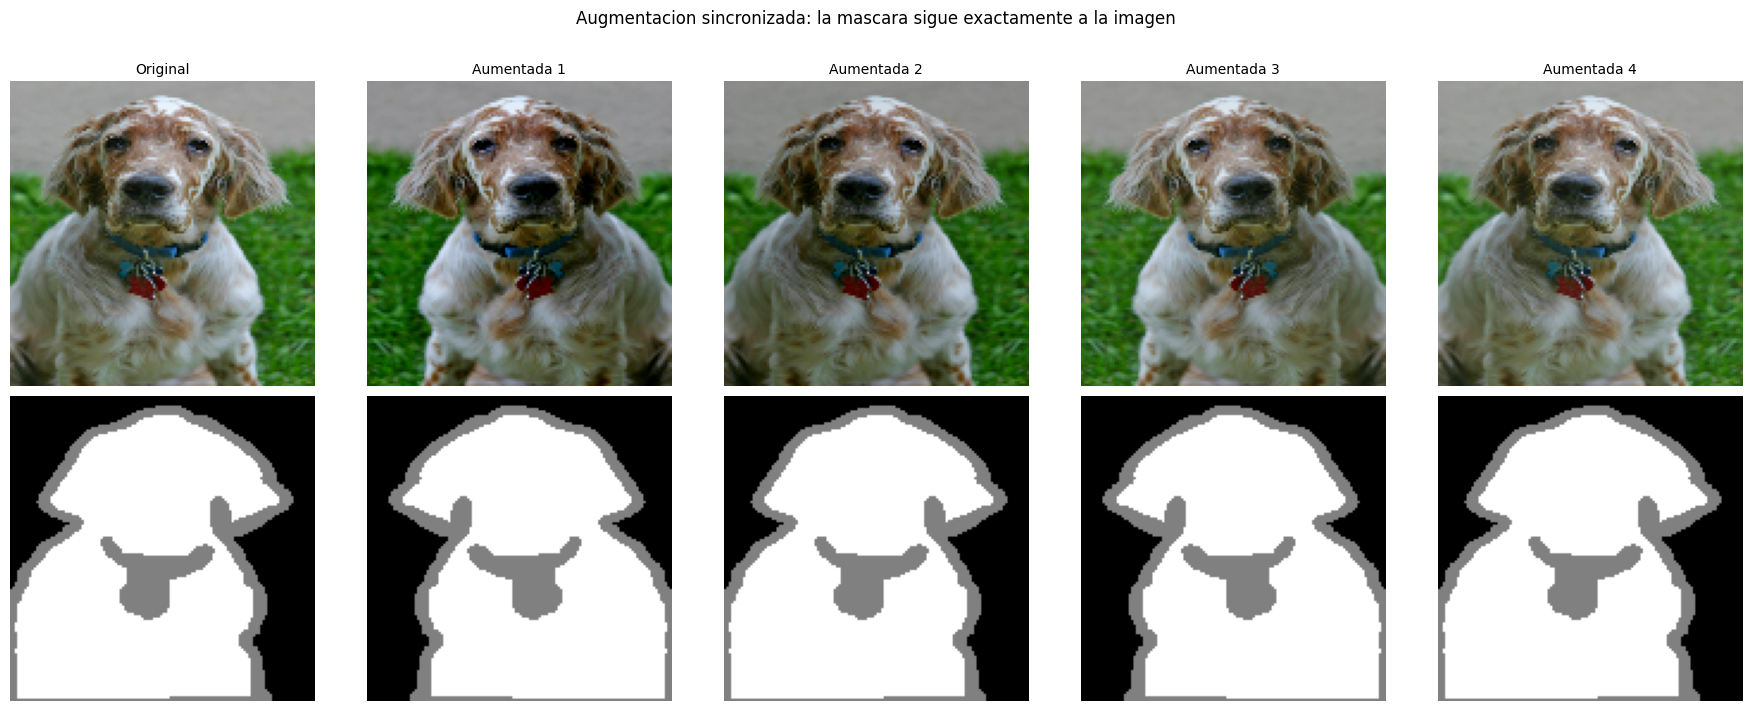

In [11]:
@tf.function
def sync_augment(img, mask):
    """
    Augmentacion sincronizada con tf.image.
    Las operaciones que afectan la geometria (flip) se aplican a ambos.
    Las que afectan solo color (brillo) se aplican solo a la imagen.
    """
    # Flip horizontal sincronizado
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_left_right(img)
        # mask es (H,W); expandir a (H,W,1) para flip y volver a contraer
        mask = tf.image.flip_left_right(mask[..., None])[..., 0]

    # Jitter de brillo solo en la imagen
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    img = tf.clip_by_value(img, 0.0, 1.0)

    return img, mask


# Aplicar augmentacion al pipeline de entrenamiento
train_ds_aug = (ds_train_raw
                .cache()
                .shuffle(BUFFER_SIZE)
                .map(sync_augment, num_parallel_calls=tf.data.AUTOTUNE)
                .batch(BATCH_SIZE, drop_remainder=True)
                .prefetch(tf.data.AUTOTUNE))

# Visualizar augmentacion
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for i, (img, mask) in enumerate(ds_train_raw.take(1)):
    axes[0, 0].imshow(img.numpy())
    axes[1, 0].imshow(mask_to_rgb(mask.numpy()))
    axes[0, 0].set_title('Original', fontsize=10)
    for col in range(1, 5):
        ia, ma = sync_augment(img, mask)
        axes[0, col].imshow(ia.numpy())
        axes[1, col].imshow(mask_to_rgb(ma.numpy()))
        axes[0, col].set_title(f'Aumentada {col}', fontsize=10)

for ax in axes.flatten(): ax.axis('off')
axes[0, 0].set_ylabel('Imagen', fontsize=11, rotation=0, labelpad=40, va='center')
axes[1, 0].set_ylabel('Mascara', fontsize=11, rotation=0, labelpad=40, va='center')
plt.suptitle('Augmentacion sincronizada: la mascara sigue exactamente a la imagen', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---

## 8. Entrenamiento y comparativa de arquitecturas

In [12]:
# Compilar y entrenar FCN con perdida combinada
fcn_model = build_fcn(N_CLASSES, (IMG_H, IMG_W, 3))
fcn_model.compile(
    optimizer=keras.optimizers.Adam(1e-3, weight_decay=1e-4),
    loss=SegLoss.combined(N_CLASSES, class_weights),
)

callbacks = [
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5),
]

print('Entrenando FCN...')
history_fcn = fcn_model.fit(
    train_ds_aug, validation_data=val_ds,
    epochs=20, callbacks=callbacks, verbose=2,
)

Entrenando FCN...
Epoch 1/20
184/184 - 34s - 186ms/step - loss: 0.8391 - val_loss: 0.8505 - learning_rate: 0.0010
Epoch 2/20
184/184 - 19s - 102ms/step - loss: 0.6947 - val_loss: 0.7694 - learning_rate: 0.0010
Epoch 3/20
184/184 - 11s - 57ms/step - loss: 0.6437 - val_loss: 0.8757 - learning_rate: 0.0010
Epoch 4/20
184/184 - 7s - 40ms/step - loss: 0.6141 - val_loss: 0.6189 - learning_rate: 0.0010
Epoch 5/20
184/184 - 8s - 41ms/step - loss: 0.5830 - val_loss: 0.6053 - learning_rate: 0.0010
Epoch 6/20
184/184 - 9s - 47ms/step - loss: 0.5669 - val_loss: 0.6447 - learning_rate: 0.0010
Epoch 7/20
184/184 - 8s - 41ms/step - loss: 0.5520 - val_loss: 0.5950 - learning_rate: 0.0010
Epoch 8/20
184/184 - 11s - 59ms/step - loss: 0.5380 - val_loss: 0.5736 - learning_rate: 0.0010
Epoch 9/20
184/184 - 11s - 60ms/step - loss: 0.5271 - val_loss: 0.5913 - learning_rate: 0.0010
Epoch 10/20
184/184 - 9s - 46ms/step - loss: 0.5167 - val_loss: 0.5858 - learning_rate: 0.0010
Epoch 11/20
184/184 - 8s - 42ms/st

In [13]:
# Compilar y entrenar U-Net
unet_model = build_unet(N_CLASSES, (IMG_H, IMG_W, 3), f=32)
unet_model.compile(
    optimizer=keras.optimizers.Adam(1e-3, weight_decay=1e-4),
    loss=SegLoss.combined(N_CLASSES, class_weights),
)

print('Entrenando U-Net...')
history_unet = unet_model.fit(
    train_ds_aug, validation_data=val_ds,
    epochs=20, callbacks=callbacks, verbose=2,
)

Entrenando U-Net...
Epoch 1/20
184/184 - 49s - 266ms/step - loss: 0.8289 - val_loss: 2.0346 - learning_rate: 0.0010
Epoch 2/20
184/184 - 20s - 108ms/step - loss: 0.6285 - val_loss: 0.7477 - learning_rate: 0.0010
Epoch 3/20
184/184 - 19s - 104ms/step - loss: 0.5484 - val_loss: 0.5560 - learning_rate: 0.0010
Epoch 4/20
184/184 - 19s - 104ms/step - loss: 0.4996 - val_loss: 0.5426 - learning_rate: 0.0010
Epoch 5/20
184/184 - 20s - 107ms/step - loss: 0.4736 - val_loss: 0.4915 - learning_rate: 0.0010
Epoch 6/20
184/184 - 22s - 121ms/step - loss: 0.4454 - val_loss: 0.4620 - learning_rate: 0.0010
Epoch 7/20
184/184 - 19s - 102ms/step - loss: 0.4329 - val_loss: 0.5444 - learning_rate: 0.0010
Epoch 8/20
184/184 - 19s - 103ms/step - loss: 0.4237 - val_loss: 0.4541 - learning_rate: 0.0010
Epoch 9/20
184/184 - 19s - 103ms/step - loss: 0.4019 - val_loss: 0.5028 - learning_rate: 0.0010
Epoch 10/20
184/184 - 19s - 103ms/step - loss: 0.3980 - val_loss: 0.4194 - learning_rate: 0.0010
Epoch 11/20
184/184

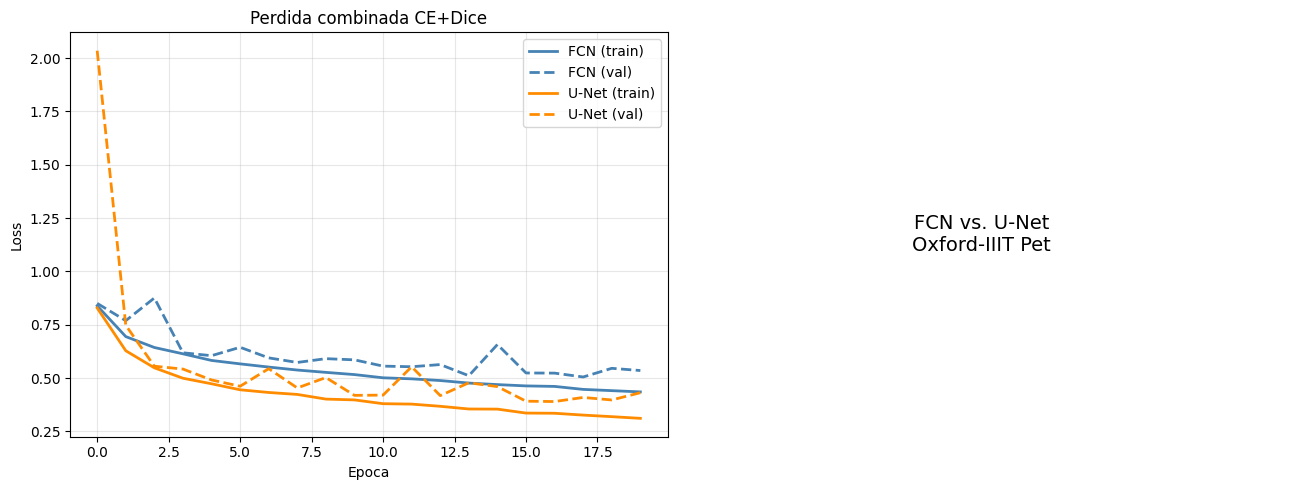

In [14]:
# Curvas comparativas de perdida
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for hist, name, color in [(history_fcn, 'FCN', 'steelblue'),
                          (history_unet, 'U-Net', 'darkorange')]:
    axes[0].plot(hist.history['loss'],     label=f'{name} (train)', color=color, lw=2)
    axes[0].plot(hist.history['val_loss'], label=f'{name} (val)',   color=color, lw=2, linestyle='--')

axes[0].set(title='Perdida combinada CE+Dice', xlabel='Epoca', ylabel='Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].axis('off')
axes[1].text(0.5, 0.5, 'FCN vs. U-Net\nOxford-IIIT Pet',
             ha='center', va='center', fontsize=14)
plt.tight_layout()
plt.show()

---

## 9. Analisis de resultados

In [15]:
fcn_res  = evaluate(fcn_model,  test_ds, N_CLASSES)
unet_res = evaluate(unet_model, test_ds, N_CLASSES)

print('Resultados en test set')
print('=' * 60)
print(f'{"Metrica":<20} {"FCN":>10} {"U-Net":>10}')
print('-' * 60)
for key, label in [('pixel_acc','Pixel Accuracy'), ('mIoU','mIoU'), ('mean_dice','Mean Dice')]:
    print(f'{label:<20} {fcn_res[key]:>10.4f} {unet_res[key]:>10.4f}')

print('\nIoU y Dice por clase:')
print(f'{"Clase":<15} {"IoU FCN":>9} {"IoU UNet":>9} {"Dice FCN":>9} {"Dice UNet":>9}')
print('-' * 60)
fmt = lambda v: f'{v:.4f}' if not np.isnan(v) else '  N/A '
for c in range(N_CLASSES):
    print(f'{CLASS_NAMES[c]:<15} '
          f'{fmt(fcn_res["iou_per_class"][c]):>9} '
          f'{fmt(unet_res["iou_per_class"][c]):>9} '
          f'{fmt(fcn_res["dice_per_class"][c]):>9} '
          f'{fmt(unet_res["dice_per_class"][c]):>9}')

Resultados en test set
Metrica                     FCN      U-Net
------------------------------------------------------------
Pixel Accuracy           0.8377     0.8625
mIoU                     0.6456     0.6967
Mean Dice                0.7678     0.8112

IoU y Dice por clase:
Clase             IoU FCN  IoU UNet  Dice FCN Dice UNet
------------------------------------------------------------
Mascota            0.7127    0.7586    0.8323    0.8627
Fondo              0.8331    0.8434    0.9089    0.9151
Borde              0.3910    0.4879    0.5622    0.6558


Predicciones de U-Net en test set:


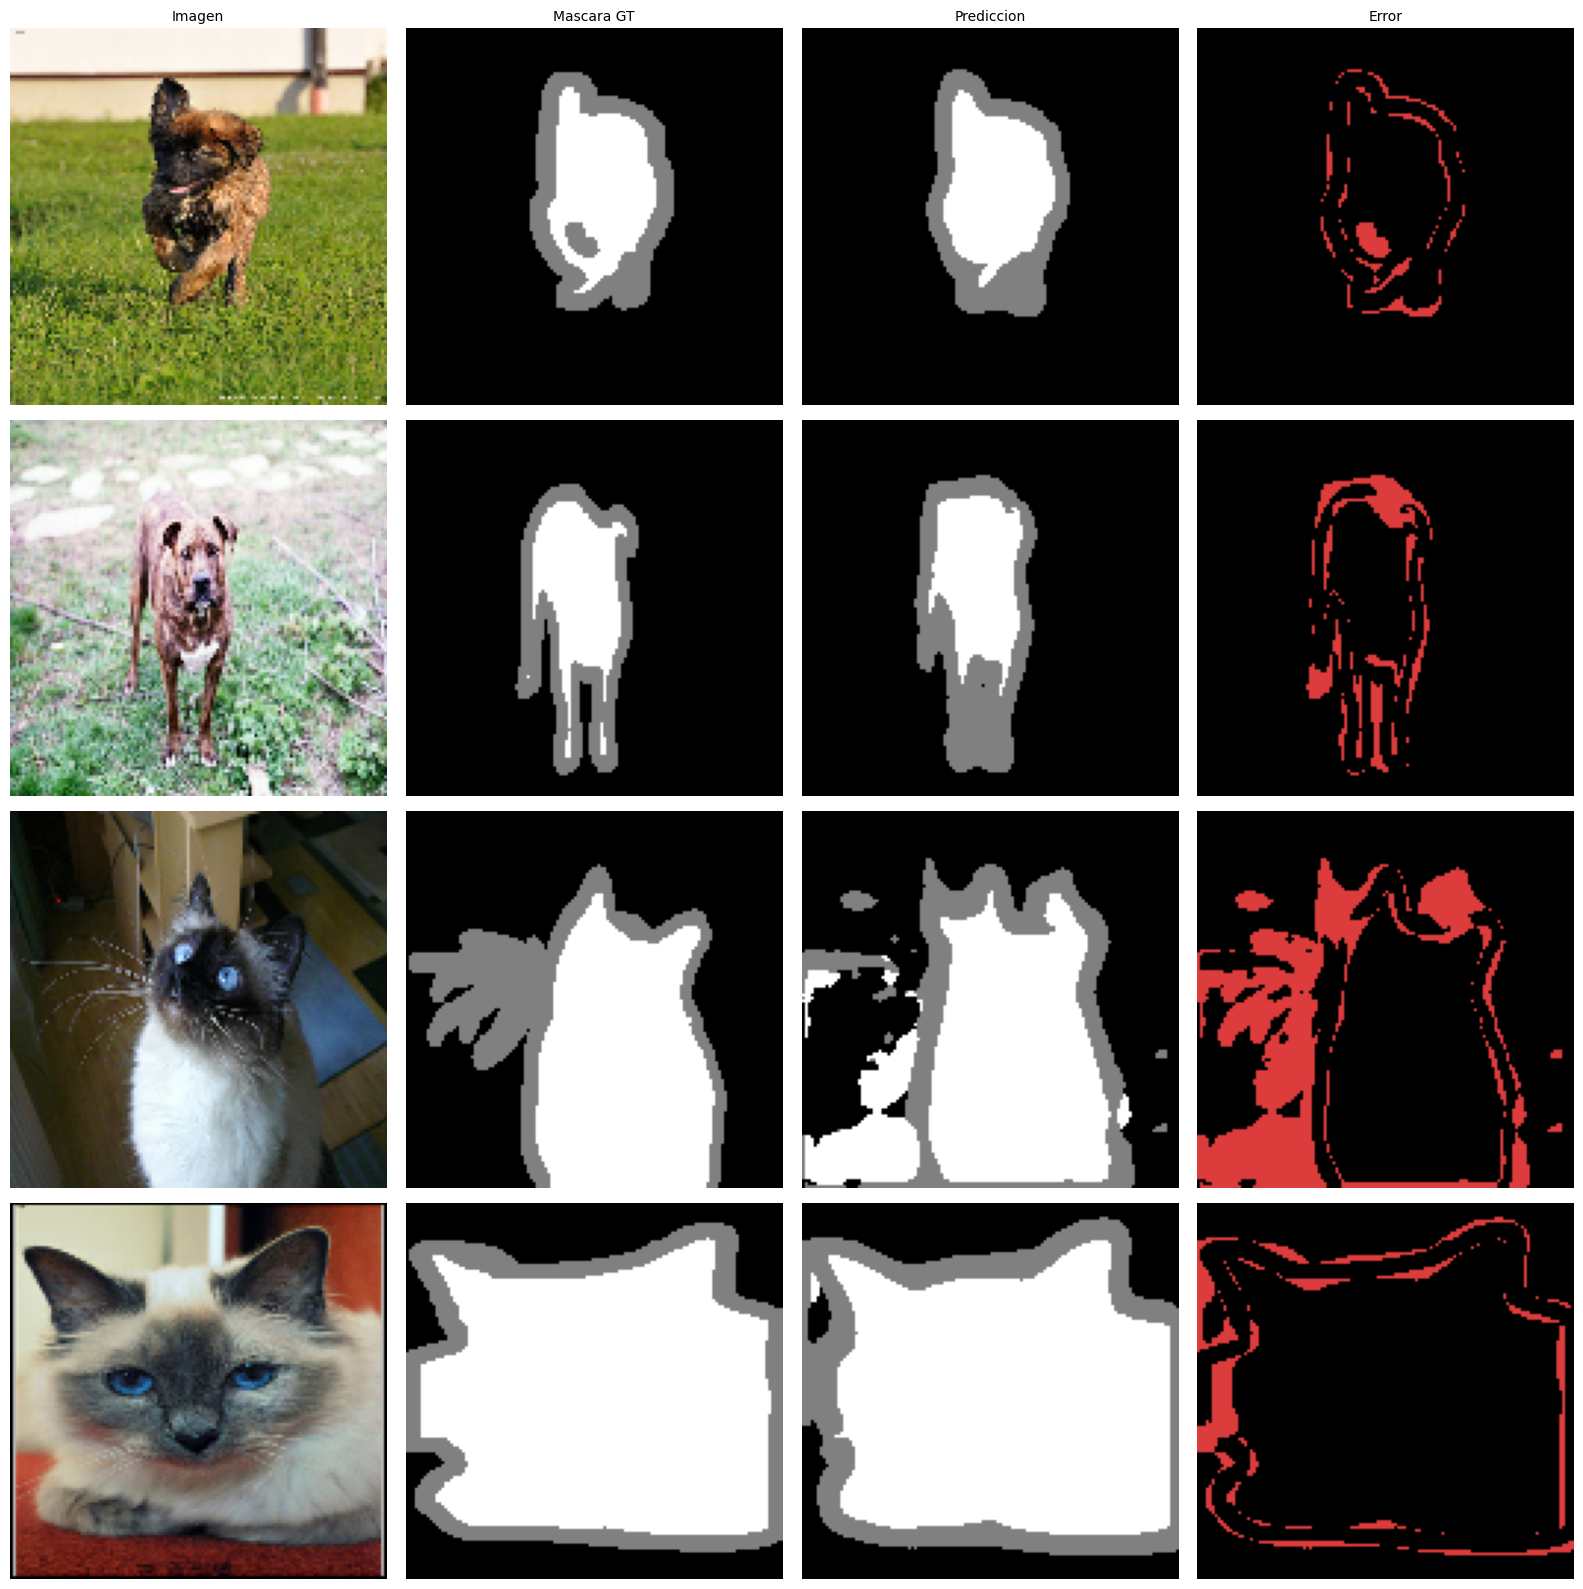

In [16]:
def visualize_predictions(model, dataset, n=4):
    """Muestra imagen / mascara GT / prediccion / mapa de error."""
    fig, axes = plt.subplots(n, 4, figsize=(16, n*4))

    for row, (imgs, masks) in enumerate(dataset.take(n)):
        img    = imgs[0].numpy()
        mask_t = masks[0].numpy()
        logits = model(imgs[:1], training=False)
        pred   = tf.argmax(logits, axis=-1)[0].numpy()

        # Mapa de error
        err = np.zeros((*mask_t.shape, 3), dtype=np.uint8)
        err[(mask_t != pred)] = [220, 60, 60]

        miou_i = float(np.nanmean(iou_per_class(mask_t, pred, N_CLASSES)))

        axes[row, 0].imshow(img)
        axes[row, 1].imshow(mask_to_rgb(mask_t))
        axes[row, 2].imshow(mask_to_rgb(pred))
        axes[row, 3].imshow(err)
        for ax in axes[row]: ax.axis('off')
        axes[row, 0].set_ylabel(f'mIoU={miou_i:.3f}', fontsize=9, rotation=0,
                                labelpad=55, va='center')

    for ax, t in zip(axes[0], ['Imagen', 'Mascara GT', 'Prediccion', 'Error']):
        ax.set_title(t, fontsize=10)
    plt.tight_layout()
    plt.show()


print('Predicciones de U-Net en test set:')
visualize_predictions(unet_model, test_ds, n=4)

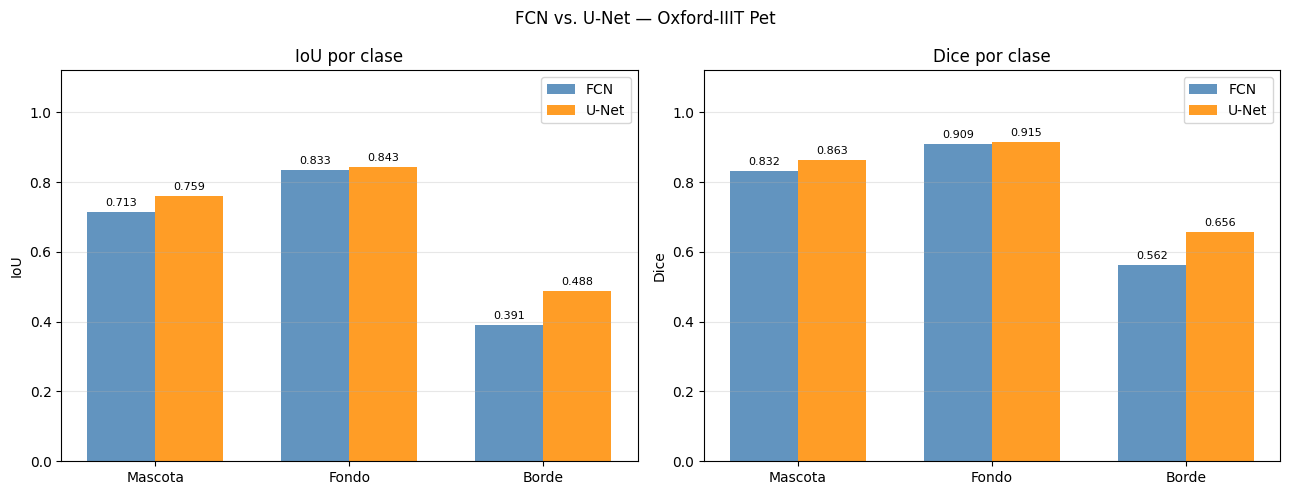

In [17]:
# Comparativa de IoU y Dice por clase
x, w = np.arange(N_CLASSES), 0.35
fi   = [v if not np.isnan(v) else 0 for v in fcn_res['iou_per_class']]
ui   = [v if not np.isnan(v) else 0 for v in unet_res['iou_per_class']]
fd   = [v if not np.isnan(v) else 0 for v in fcn_res['dice_per_class']]
ud   = [v if not np.isnan(v) else 0 for v in unet_res['dice_per_class']]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, fv, uv, lbl in [(axes[0], fi, ui, 'IoU'), (axes[1], fd, ud, 'Dice')]:
    b1 = ax.bar(x - w/2, fv, w, label='FCN',   color='steelblue',  alpha=0.85)
    b2 = ax.bar(x + w/2, uv, w, label='U-Net', color='darkorange', alpha=0.85)
    ax.bar_label(b1, fmt='%.3f', padding=3, fontsize=8)
    ax.bar_label(b2, fmt='%.3f', padding=3, fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES)
    ax.set_ylabel(lbl); ax.set_ylim(0, 1.12)
    ax.set_title(f'{lbl} por clase'); ax.legend()
    ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('FCN vs. U-Net — Oxford-IIIT Pet', fontsize=12)
plt.tight_layout()
plt.show()

In [18]:
# Tabla resumen: cuando usar cada arquitectura y perdida
print('Guia de seleccion de arquitectura y perdida')
print('=' * 100)

arq = [
    ('FCN',         'Encoder CNN + Upsample bilineal',     'Bajo',  'Bajo',     'Prototipos rapidos'),
    ('U-Net',       'Encoder-Decoder + Skip Connections',  'Medio', 'Alto',     'Estandar medico/general'),
    ('U-Net++',     'Skip Connections anidadas',           'Medio', 'Muy Alto', 'Maxima precision de borde'),
    ('DeepLab v3+', 'Dilated Conv + ASPP + Decoder',       'Alto',  'Muy Alto', 'Multiples escalas'),
    ('SegFormer',   'Transformer Encoder + MLP Decoder',    'Alto',  'Muy Alto', 'Datasets grandes'),
    ('SAM',         'ViT-H + Prompt Encoder',              'Muy Alto', 'SOTA',  'Zero-shot'),
]
print(f'{"Arquitectura":<15} {"Componentes":<35} {"Params":<10} {"Precision":<12} {"Uso"}')
print('-' * 100)
for r in arq:
    print(f'{r[0]:<15} {r[1]:<35} {r[2]:<10} {r[3]:<12} {r[4]}')

print()
print('=' * 100)
loss_tabla = [
    ('Cross-Entropy',  'Clases balanceadas, baseline'),
    ('Weighted CE',    'Desbalance moderado'),
    ('Dice Loss',      'Objetos pequenos, desbalance severo, medico'),
    ('Focal Loss',     'Desbalance + pixeles dificiles (bordes, oclusiones)'),
    ('CE + Dice',      'Opcion robusta general'),
]
print(f'{"Perdida":<20} {"Cuando usarla"}')
print('-' * 80)
for r in loss_tabla:
    print(f'{r[0]:<20} {r[1]}')

Guia de seleccion de arquitectura y perdida
Arquitectura    Componentes                         Params     Precision    Uso
----------------------------------------------------------------------------------------------------
FCN             Encoder CNN + Upsample bilineal     Bajo       Bajo         Prototipos rapidos
U-Net           Encoder-Decoder + Skip Connections  Medio      Alto         Estandar medico/general
U-Net++         Skip Connections anidadas           Medio      Muy Alto     Maxima precision de borde
DeepLab v3+     Dilated Conv + ASPP + Decoder       Alto       Muy Alto     Multiples escalas
SegFormer       Transformer Encoder + MLP Decoder   Alto       Muy Alto     Datasets grandes
SAM             ViT-H + Prompt Encoder              Muy Alto   SOTA         Zero-shot

Perdida              Cuando usarla
--------------------------------------------------------------------------------
Cross-Entropy        Clases balanceadas, baseline
Weighted CE          Desbalance modera

---

## Conclusiones

**Dataset**: Oxford-IIIT Pet con sus 3 clases (mascota / fondo / borde) es un benchmark estandar de segmentacion. La descarga automatica via `tensorflow_datasets` lo hace ideal para experimentos reproducibles.

**FCN vs. U-Net**: la FCN limita su precision de borde porque el upsampling bilineal desde $H/16$ no recupera detalles finos. Las skip connections de U-Net proveen detalle espacial en cada nivel de resolucion, lo que se traduce en IoU y Dice superiores especialmente en la clase **borde**.

**Funciones de perdida**: la Cross-Entropy pura falla con desbalance porque el gradiente lo domina la clase mayoritaria. Dice Loss trata todas las clases por igual independientemente de su frecuencia. La perdida combinada CE + Dice es la mas robusta: CE aporta convergencia estable y Dice optimiza la superposicion region a region.

**Metricas**: la Pixel Accuracy es engañosa con desbalance. **mIoU** y **Dice por clase** son las referencias porque promedian sin sesgo hacia la clase mayoritaria.

---

## Referencias

- Long, J., Shelhamer, E., & Darrell, T. (2015). Fully convolutional networks for semantic segmentation. *CVPR 2015*.
- Ronneberger, O., Fischer, P., & Brox, T. (2015). U-Net: Convolutional networks for biomedical image segmentation. *MICCAI 2015*.
- Lin, T.Y., et al. (2017). Focal loss for dense object detection. *ICCV 2017*.
- Parkhi, O.M., et al. (2012). Cats and Dogs. *CVPR 2012* — Oxford-IIIT Pet dataset.